### EX: Predicting Component Failure (LogReg, LDA, & QDA)

In this lab, we will simulate engine telemetry and compare three statistical classification models to predict engine failure. You will execute the following steps:

* **Generate Data:** Create a simulated dataset of engine sensor readings (vibration, temperature, pressure). We will specifically engineer the "failure" data to have a wider variance (erratic behavior) than the "operational" data.
* **Split Data:** Divide the data into a training set (to teach the models) and a testing set (to evaluate their performance on unseen data).
* **Train Models:** Fit a Logistic Regression model, an LDA model, and a QDA model to the training data.
* **Evaluate:** Plot a Confusion Matrix for all three models side-by-side to visualize the real-world operational impacts of false positives and false negatives.

In [1]:
#Only run this cell after selecting your kernel
!pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas

Sample Engine Telemetry Data:
   Vibration_Hz  Temp_Celsius  Pressure_Drop_PSI  Failure_Status
0     -1.080073     -1.525351          -1.917930               0
1     -1.219710     -0.949860          -0.913463               0
2     -2.092225     -1.232171           1.741761               0
3      0.425801     -1.066283          -0.150923               0
4     -0.326744     -1.398371          -0.275178               0 



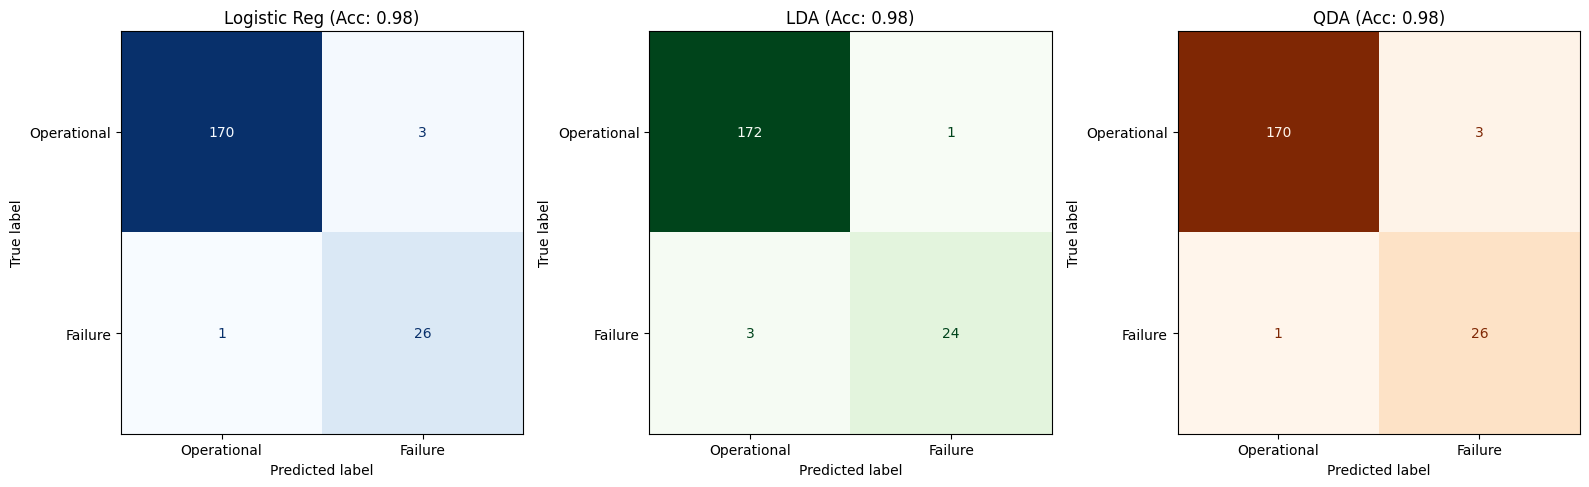

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# 1. Generate Simulated Turbofan Engine Data
# We simulate 1000 engines. 85% operational, 15% failing. 
X, y = make_classification(n_samples=1000, n_features=3, n_informative=3, 
                           n_redundant=0, weights=[0.85, 0.15], 
                           class_sep=1.2, random_state=42)

# Display the data as a table to understand its structure
df_telemetry = pd.DataFrame(X, columns=['Vibration_Hz', 'Temp_Celsius', 'Pressure_Drop_PSI'])
df_telemetry['Failure_Status'] = y
print("Sample Engine Telemetry Data:")
print(df_telemetry.head(), "\n")

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Models
# Model A: Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)

# Model B: Linear Discriminant Analysis (Assumes equal variance)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_preds = lda.predict(X_test)

# Model C: Quadratic Discriminant Analysis (Allows different variances)
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
qda_preds = qda.predict(X_test)

# 4. Plot Confusion Matrices for Operational Impact
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Logistic Regression Plot
ConfusionMatrixDisplay.from_predictions(y_test, log_preds, ax=axes[0], 
                                        display_labels=['Operational', 'Failure'], cmap='Blues', colorbar=False)
axes[0].set_title(f'Logistic Reg (Acc: {accuracy_score(y_test, log_preds):.2f})')

# LDA Plot
ConfusionMatrixDisplay.from_predictions(y_test, lda_preds, ax=axes[1], 
                                        display_labels=['Operational', 'Failure'], cmap='Greens', colorbar=False)
axes[1].set_title(f'LDA (Acc: {accuracy_score(y_test, lda_preds):.2f})')

# QDA Plot
ConfusionMatrixDisplay.from_predictions(y_test, qda_preds, ax=axes[2], 
                                        display_labels=['Operational', 'Failure'], cmap='Oranges', colorbar=False)
axes[2].set_title(f'QDA (Acc: {accuracy_score(y_test, qda_preds):.2f})')

plt.tight_layout()
plt.show()


### Interpreting the Results

In this scenario, our dataset is imbalanced—most engines are operational (85%). The visualization above uses a **Confusion Matrix**, which is much more useful than flat accuracy for military logistics.

When evaluating these matrices, commanders must weigh two distinct risks:

* **Bottom-Left (False Negatives):** The model predicted the engine was "Operational", but it actually "Failed". In the real world, this means a catastrophic in-flight emergency. This is the worst-case scenario.
* **Top-Right (False Positives):** The model predicted a "Failure", but the engine was fine. This results in wasted maintenance hours and grounding a healthy aircraft.

**Comparing the Models:**
Because failing engines in this dataset behave more erratically (higher variance) than smoothly operating engines, LDA struggles slightly because it assumes the variance is identical for both states.

Notice how **QDA** adapts to this reality. By calculating a unique covariance matrix for the failing engines, QDA is often able to capture a more complex, curved boundary. Depending on the exact random generation of your data, you will likely see QDA alter the balance of False Positives and False Negatives compared to the linear models. If QDA successfully reduces the False Negatives (bottom-left) even at the cost of a few more False Positives (top-right), it is the superior model for aircraft safety, proving that understanding the mathematical assumptions of your algorithm directly impacts human lives.